<a href="https://colab.research.google.com/github/dmora20/EconomiaUAQ/blob/main/data_analyst_assignment_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analyst Assignment 2
### Training Impact on Sales Performance

**Objetivo:** Analizar cómo el entrenamiento de empleados impacta el desempeño de ventas e identificar patrones accionables.

**Tablas disponibles:**
- `Employee_Data` — información de empleados (2,532 registros)
- `Completed_Trainings` — entrenamientos completados (1,982 registros)
- `Performance Data` — oportunidades de ventas (607 registros)


## Setup — Carga de librerías y datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Estilo visual uniforme
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# ── Carga de datos ──────────────────────────────────────────────────────────
FILE = 'Assignment_2.xlsx'

emp   = pd.read_excel(FILE, sheet_name='Employee_Data')
train = pd.read_excel(FILE, sheet_name='Completed_Trainings')
perf  = pd.read_excel(FILE, sheet_name='Performance Data')

print(f'Employee_Data:      {emp.shape[0]:,} filas x {emp.shape[1]} columnas')
print(f'Completed_Trainings:{train.shape[0]:,} filas x {train.shape[1]} columnas')
print(f'Performance Data:   {perf.shape[0]:,} filas x {perf.shape[1]} columnas')

Employee_Data:      2,532 filas x 10 columnas
Completed_Trainings:1,982 filas x 2 columnas
Performance Data:   607 filas x 12 columnas


In [ ]:
# Vista rápida de cada tabla
print('=== Employee_Data (primeras 3 filas) ===')
display(emp.head(3))

print('\n=== Completed_Trainings (primeras 3 filas) ===')
display(train.head(3))

print('\n=== Performance Data (primeras 3 filas) ===')
display(perf.head(3))

=== Employee_Data (primeras 3 filas) ===


,Employee_ID,SVP Leader,Business Title,Cost Center,Cost Center Family,Length of service,Leave Status,is People Manager?,Region,Manager IC Helper
0,1,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,20,Active,False,EMEA,IC
1,2,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,13,Active,False,EMEA,IC
2,3,Leader 1,Senior Commercial Account Executive,552 Mid-Market AE,Mid-Market,44,Active,False,EMEA,IC



=== Completed_Trainings (primeras 3 filas) ===


,Employee_ID,Training_Completed
0,2.0,Sell More Suite SKU
1,5.0,Sell More Suite SKU
2,9.0,Sell More Suite SKU



=== Performance Data (primeras 3 filas) ===


,Employee_ID,Opportunity ID,Type,Stage 2+ Date,Stage,Close Date,Product Rate Plan Charge,Product Name,Add-On ARR (converted) Currency,Add-On ARR (converted),Total Commissionable ARR (converted) Currency,Total Commissionable ARR (converted)
0,963.0,10000,New Business,2016-10-16,03 - Solution Review,2018-06-03,Suite Subscription,Support: Addons,USD,25771,USD,225073
1,435.0,10005,Expansion,2017-12-14,02 - Discovery,2018-03-02,Suite Subscription,Support: Addons,USD,6861,USD,4561
2,33.0,10010,Expansion,2017-12-17,02 - Discovery,2018-06-09,Suite Subscription,Support: Addons,USD,21198,USD,11215


---
## Pregunta 1 — Tasa de Completación de Entrenamientos por Segmento

**Objetivo:** Calcular el porcentaje de empleados *requeridos* que completaron cada curso,
segmentado por SVP Leader y por Región.

**Reglas de elegibilidad (quién DEBE tomar cada curso):**
1. Empleados **en licencia** (`Leave Status = 'On Leave'`) están **exentos** de todos los cursos.
2. El curso **'Sell More Suite SKU'** NO es requerido para empleados en la familia de cost center **'Advocacy'**.
3. Los cursos **'Suite/Automation Technical Lab'** y **'Advanced Suite Bots Lab Course'**
   **solo** son requeridos para empleados en **'PreSales'** o **'Services'**.

> **Nota metodológica:** La tasa se calcula como
> `Completación (%) = Empleados que completaron el curso / Empleados requeridos × 100`


In [ ]:
# ── 1A. Filtrar solo empleados activos (no en licencia) ────────────────────
active = emp[emp['Leave Status'] == 'Active'].copy()
print(f'Empleados totales: {len(emp):,}')
print(f'En licencia (exentos): {(emp["Leave Status"] == "On Leave").sum():,}')
print(f'Empleados activos (base de análisis): {len(active):,}')


Empleados totales: 2,532
En licencia (exentos): 99
Empleados activos (base de análisis): 2,433


In [ ]:
# ── 1B. Definir elegibilidad por curso ─────────────────────────────────────
COURSES = [
    'Sell More Suite SKU',
    'Suite/Automation Technical Lab',
    'Advanced Suite Bots Lab Course'
]

def get_required(course, active_df):
    """Devuelve el subconjunto de activos que DEBEN tomar el curso."""
    if course == 'Sell More Suite SKU':
        return active_df[active_df['Cost Center Family'] != 'Advocacy']
    elif course in ['Suite/Automation Technical Lab', 'Advanced Suite Bots Lab Course']:
        return active_df[active_df['Cost Center Family'].isin(['PreSales', 'Services'])]
    return active_df

# Verificar conteos de elegibles por curso
for c in COURSES:
    req = get_required(c, active)
    print(f'{c:<40} → {len(req):,} empleados requeridos')

Sell More Suite SKU                      → 1,941 empleados requeridos
Suite/Automation Technical Lab           → 429 empleados requeridos
Advanced Suite Bots Lab Course           → 429 empleados requeridos


In [ ]:
# ── 1C. Calcular tasas de completación por curso y segmento ────────────────
results = []

for course in COURSES:
    required = get_required(course, active)
    completed_ids = set(train.loc[train['Training_Completed'] == course, 'Employee_ID'])

    for seg_col in ['SVP Leader', 'Region']:
        for seg_val in sorted(required[seg_col].unique()):
            seg_emp = required[required[seg_col] == seg_val]
            n_req  = len(seg_emp)
            n_comp = seg_emp['Employee_ID'].isin(completed_ids).sum()
            rate   = round(n_comp / n_req * 100, 1) if n_req > 0 else np.nan

            results.append({
                'Course': course,
                'Segment Type': seg_col,
                'Segment': seg_val,
                'Required': n_req,
                'Completed': int(n_comp),
                'Completion Rate (%)': rate
            })

df_q1 = pd.DataFrame(results)
print('Resultados calculados:', len(df_q1), 'combinaciones curso-segmento')

Resultados calculados: 32 combinaciones curso-segmento


In [ ]:
# ── 1D. Tabla resumen — por Región ─────────────────────────────────────────
q1_region = (
    df_q1[df_q1['Segment Type'] == 'Region']
    .pivot(index='Segment', columns='Course', values='Completion Rate (%)')
    .rename_axis(None, axis=1)
    .reset_index()
    .rename(columns={'Segment': 'Región'})
)
display(q1_region.style
    .format({c: '{:.1f}%' for c in COURSES})
    .background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=100)
    .set_caption('Tasa de Completación por Región')
)

,Región,Advanced Suite Bots Lab Course,Sell More Suite SKU,Suite/Automation Technical Lab
0,APAC,81.2%,7.7%,81.2%
1,EMEA,88.6%,43.2%,88.6%
2,LATAM,97.9%,31.6%,97.9%
3,North America,94.7%,53.9%,94.7%


In [ ]:
# ── 1E. Tabla resumen — por SVP Leader ─────────────────────────────────────
q1_leader = (
    df_q1[
        (df_q1['Segment Type'] == 'SVP Leader') &
        (df_q1['Course'] == 'Sell More Suite SKU')
    ][['Segment','Required','Completed','Completion Rate (%)']]
    .rename(columns={'Segment': 'SVP Leader'})
    .sort_values('Completion Rate (%)', ascending=False)
    .reset_index(drop=True)
)
display(q1_leader.style
    .format({'Completion Rate (%)': '{:.1f}%'})
    .background_gradient(subset='Completion Rate (%)', cmap='RdYlGn', vmin=0, vmax=100)
    .set_caption('Sell More Suite SKU — por SVP Leader')
)

,SVP Leader,Required,Completed,Completion Rate (%)
0,Leader 4,150,105,70.0%
1,Leader 11,71,43,60.6%
2,Leader 9,184,103,56.0%
3,Leader 6,8,4,50.0%
4,Leader 7,42,21,50.0%
5,Leader 10,297,140,47.1%
6,Leader 12,47,22,46.8%
7,Leader 1,182,77,42.3%
8,Leader 3,280,114,40.7%
9,Leader 5,510,138,27.1%


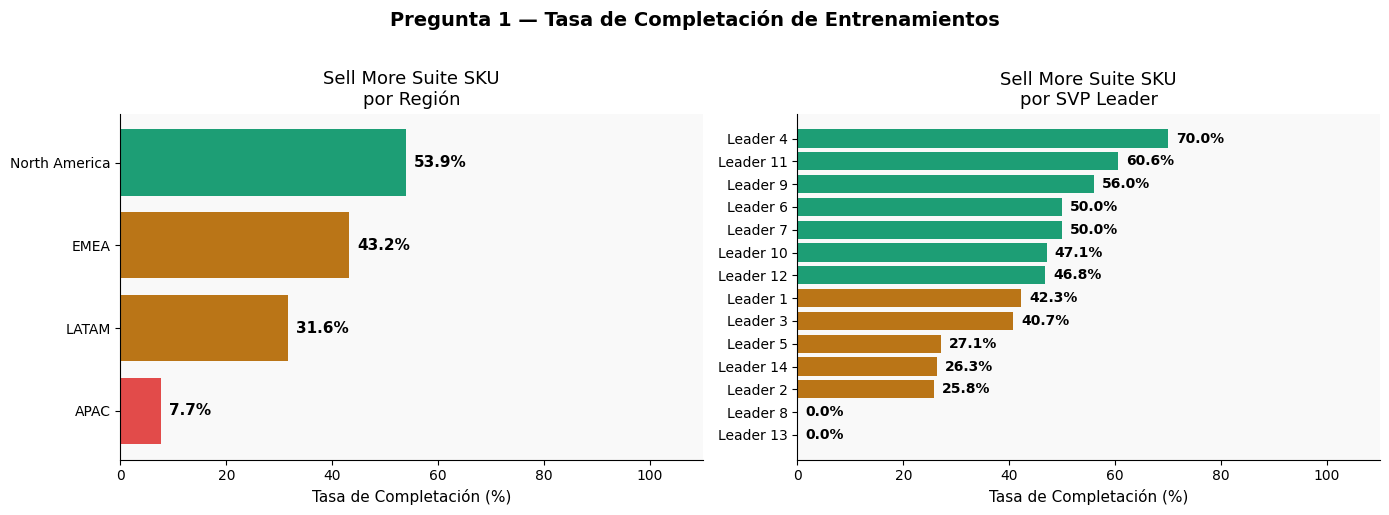

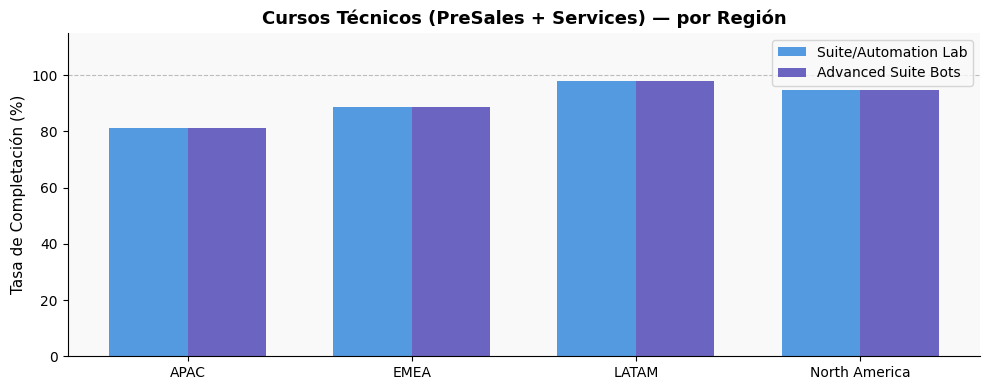

In [ ]:
# ── 1F. Visualización ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pregunta 1 — Tasa de Completación de Entrenamientos', fontsize=14, fontweight='bold', y=1.02)

COLORS_REGION = ['#E24B4A', '#BA7517', '#BA7517', '#1D9E75']  # APAC rojo, EMEA/LATAM amber, NA verde

# Chart 1: Sell More Suite SKU por Región
ax1 = axes[0]
data_r = df_q1[(df_q1['Course'] == 'Sell More Suite SKU') & (df_q1['Segment Type'] == 'Region')].sort_values('Completion Rate (%)')
bars = ax1.barh(data_r['Segment'], data_r['Completion Rate (%)'],
                color=['#E24B4A' if v < 20 else '#BA7517' if v < 45 else '#1D9E75' for v in data_r['Completion Rate (%)']])
ax1.set_xlim(0, 110)
ax1.set_xlabel('Tasa de Completación (%)')
ax1.set_title('Sell More Suite SKU\npor Región')
for bar, val in zip(bars, data_r['Completion Rate (%)']):
    ax1.text(val + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

# Chart 2: SVP Leader
ax2 = axes[1]
data_l = df_q1[(df_q1['Course'] == 'Sell More Suite SKU') & (df_q1['Segment Type'] == 'SVP Leader')].sort_values('Completion Rate (%)')
bars2 = ax2.barh(data_l['Segment'], data_l['Completion Rate (%)'],
                 color=['#E24B4A' if v == 0 else '#BA7517' if v < 45 else '#1D9E75' for v in data_l['Completion Rate (%)']])
ax2.set_xlim(0, 110)
ax2.set_xlabel('Tasa de Completación (%)')
ax2.set_title('Sell More Suite SKU\npor SVP Leader')
for bar, val in zip(bars2, data_l['Completion Rate (%)']):
    ax2.text(val + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Chart 3: Cursos técnicos
fig2, ax3 = plt.subplots(figsize=(10, 4))
tech_courses = ['Suite/Automation Technical Lab', 'Advanced Suite Bots Lab Course']
data_tech = df_q1[(df_q1['Course'].isin(tech_courses)) & (df_q1['Segment Type'] == 'Region')]
pivot = data_tech.pivot(index='Segment', columns='Course', values='Completion Rate (%)')
x = np.arange(len(pivot))
w = 0.35
ax3.bar(x - w/2, pivot[tech_courses[0]], w, label='Suite/Automation Lab', color='#378ADD', alpha=0.85)
ax3.bar(x + w/2, pivot[tech_courses[1]], w, label='Advanced Suite Bots', color='#534AB7', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(pivot.index)
ax3.set_ylim(0, 115)
ax3.set_ylabel('Tasa de Completación (%)')
ax3.set_title('Cursos Técnicos (PreSales + Services) — por Región', fontweight='bold')
ax3.legend()
ax3.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

### Respuesta — Pregunta 1

#### Sell More Suite SKU
La tasa de completación global es del **40.2%** (794 de 1,941 empleados activos y requeridos),
lo que indica que la mayoría del equipo aún no ha completado este entrenamiento.

**Por Región:**
| Región | Tasa | Estado |
|---|---|---|
| APAC | **7.7%** | 🔴 Crítico — acción urgente |
| LATAM | 31.6% | 🟡 Por debajo del promedio |
| EMEA | 43.2% | 🟡 Cerca del promedio |
| North America | **53.9%** | 🟢 Mejor región |

**Por SVP Leader:**
- Líderes con 0% de completación: **Leader 8** (54 empleados) y **Leader 13** (12 empleados) — no hay ninguna completación registrada, lo que sugiere falta de adopción o un problema en el registro.
- Mejor desempeño: **Leader 4** (70.0%) y **Leader 11** (60.6%).

#### Cursos Técnicos (PreSales + Services)
Ambos cursos muestran tasas de completación muy altas (>80% en todas las regiones):
- LATAM lidera con **97.9%**
- APAC es la región más rezagada con **81.2%**, aun así un resultado sólido.

#### Recomendación
Priorizar intervención en **APAC** para Sell More Suite SKU — con 7.7% de completación y siendo la región con más empleados después de North America, representa el mayor gap absoluto del negocio.
Investigar específicamente las razones detrás del 0% de Leaders 8 y 13.


---
## Pregunta 2 — Desempeño de Account Executives: Entrenados vs No Entrenados

**Objetivo:** Determinar si existe una diferencia de desempeño entre empleados que han completado
algún entrenamiento y los que no, desde una perspectiva de ventas.

**Metodología:**
- Se considera **entrenado** a cualquier empleado con al menos un entrenamiento completado
  (independientemente del curso específico).
- El análisis se enfoca en **Individual Contributors (ICs)** — los Account Executives.
- Métricas clave: Win Rate, ARR promedio por oportunidad, Total ARR generado.
- Segmentación: Overall → por Región → por SVP Leader.

> **Nota:** Se define como 'cerrada/ganada' cualquier oportunidad en Stage `06 - Signed` o `07 - Closed`.


In [ ]:
# ── 2A. Preparación: etiqueta entrenado / no entrenado ─────────────────────
trained_ids = set(train['Employee_ID'].unique())
emp['Trained'] = emp['Employee_ID'].isin(trained_ids)
emp['Trained Label'] = emp['Trained'].map({True: 'Entrenado', False: 'No Entrenado'})

ics = emp[emp['Manager IC Helper'] == 'IC']

print('=== Headcount de ICs ===')
print(ics['Trained Label'].value_counts().to_string())
print(f'\nTotal ICs: {len(ics):,}')
print(f'% entrenados: {ics["Trained"].mean()*100:.1f}%')

=== Headcount de ICs ===
Trained Label
No Entrenado    1123
Entrenado       1000

Total ICs: 2,123
% entrenados: 47.1%


In [ ]:
# ── 2B. Preparar tabla de performance ──────────────────────────────────────
CLOSED_STAGES = ['06 - Signed', '07 - Closed']
perf['Is Closed Won'] = perf['Stage'].isin(CLOSED_STAGES)

# Merge con datos de empleado
perf_m = perf.merge(
    emp[['Employee_ID', 'Trained', 'Trained Label', 'SVP Leader', 'Region', 'Manager IC Helper']],
    on='Employee_ID', how='left'
)

# Filtrar solo ICs
ic_perf = perf_m[perf_m['Manager IC Helper'] == 'IC'].copy()
print(f'Oportunidades de ICs: {len(ic_perf):,}')
print(f'  Entrenados: {ic_perf["Trained"].sum():,}')
print(f'  No entrenados: {(~ic_perf["Trained"]).sum():,}')

Oportunidades de ICs: 601
  Entrenados: 339
  No entrenados: -940


In [ ]:
# ── 2C. Métricas globales ───────────────────────────────────────────────────
def perf_metrics(df, group_col):
    return (
        df.groupby(group_col)
        .apply(lambda x: pd.Series({
            'Total Oportunidades': len(x),
            'Cerradas/Ganadas': int(x['Is Closed Won'].sum()),
            'Win Rate (%)': round(x['Is Closed Won'].mean() * 100, 1),
            'Total ARR (M USD)': round(x['Total Commissionable ARR (converted)'].sum() / 1e6, 2),
            'Avg ARR por Opp (USD)': round(x['Total Commissionable ARR (converted)'].mean(), 0),
        }))
        .reset_index()
    )

global_metrics = perf_metrics(ic_perf, 'Trained Label')
display(global_metrics.style
    .format({
        'Win Rate (%)': '{:.1f}%',
        'Total ARR (M USD)': '${:.2f}M',
        'Avg ARR por Opp (USD)': '${:,.0f}'
    })
    .background_gradient(subset='Avg ARR por Opp (USD)', cmap='Greens')
    .set_caption('Métricas Globales — Entrenados vs No Entrenados')
)

,Trained Label,Total Oportunidades,Cerradas/Ganadas,Win Rate (%),Total ARR (M USD),Avg ARR por Opp (USD)
0,Entrenado,339.000000,46.000000,13.6%,$36.36M,"$107,243"
1,No Entrenado,262.000000,36.000000,13.7%,$20.52M,"$78,329"


In [ ]:
# ── 2D. Por Región ──────────────────────────────────────────────────────────
region_metrics = perf_metrics(ic_perf, ['Region', 'Trained Label'])
display(region_metrics.style
    .format({
        'Win Rate (%)': '{:.1f}%',
        'Total ARR (M USD)': '${:.2f}M',
        'Avg ARR por Opp (USD)': '${:,.0f}'
    })
    .background_gradient(subset='Avg ARR por Opp (USD)', cmap='Blues')
    .set_caption('Métricas por Región')
)

,Region,Trained Label,Total Oportunidades,Cerradas/Ganadas,Win Rate (%),Total ARR (M USD),Avg ARR por Opp (USD)
0,APAC,Entrenado,8.000000,0.000000,0.0%,$0.74M,"$92,490"
1,APAC,No Entrenado,82.000000,8.000000,9.8%,$8.46M,"$103,160"
2,EMEA,Entrenado,121.000000,22.000000,18.2%,$13.43M,"$110,995"
3,EMEA,No Entrenado,72.000000,14.000000,19.4%,$4.97M,"$69,050"
4,LATAM,Entrenado,7.000000,1.000000,14.3%,$0.46M,"$65,556"
5,LATAM,No Entrenado,18.000000,6.000000,33.3%,$0.84M,"$46,658"
6,North America,Entrenado,203.000000,23.000000,11.3%,$21.73M,"$107,026"
7,North America,No Entrenado,90.000000,8.000000,8.9%,$6.25M,"$69,462"


In [ ]:
# ── 2E. Por SVP Leader ──────────────────────────────────────────────────────
leader_metrics = perf_metrics(ic_perf, ['SVP Leader', 'Trained Label'])
display(leader_metrics.style
    .format({
        'Win Rate (%)': '{:.1f}%',
        'Total ARR (M USD)': '${:.2f}M',
        'Avg ARR por Opp (USD)': '${:,.0f}'
    })
    .background_gradient(subset='Avg ARR por Opp (USD)', cmap='Blues')
    .set_caption('Métricas por SVP Leader')
)

,SVP Leader,Trained Label,Total Oportunidades,Cerradas/Ganadas,Win Rate (%),Total ARR (M USD),Avg ARR por Opp (USD)
0,Leader 1,Entrenado,101.000000,17.000000,16.8%,$13.05M,"$129,206"
1,Leader 1,No Entrenado,99.000000,11.000000,11.1%,$9.46M,"$95,586"
2,Leader 10,No Entrenado,2.000000,0.000000,0.0%,$1.49M,"$745,790"
3,Leader 11,Entrenado,31.000000,0.000000,0.0%,$4.55M,"$146,834"
4,Leader 11,No Entrenado,22.000000,0.000000,0.0%,$1.95M,"$88,522"
5,Leader 13,No Entrenado,7.000000,0.000000,0.0%,$0.87M,"$124,532"
6,Leader 14,Entrenado,5.000000,0.000000,0.0%,$0.59M,"$118,210"
7,Leader 14,No Entrenado,10.000000,0.000000,0.0%,$0.84M,"$83,996"
8,Leader 2,Entrenado,5.000000,0.000000,0.0%,$0.42M,"$84,872"
9,Leader 2,No Entrenado,10.000000,5.000000,50.0%,$0.71M,"$71,063"


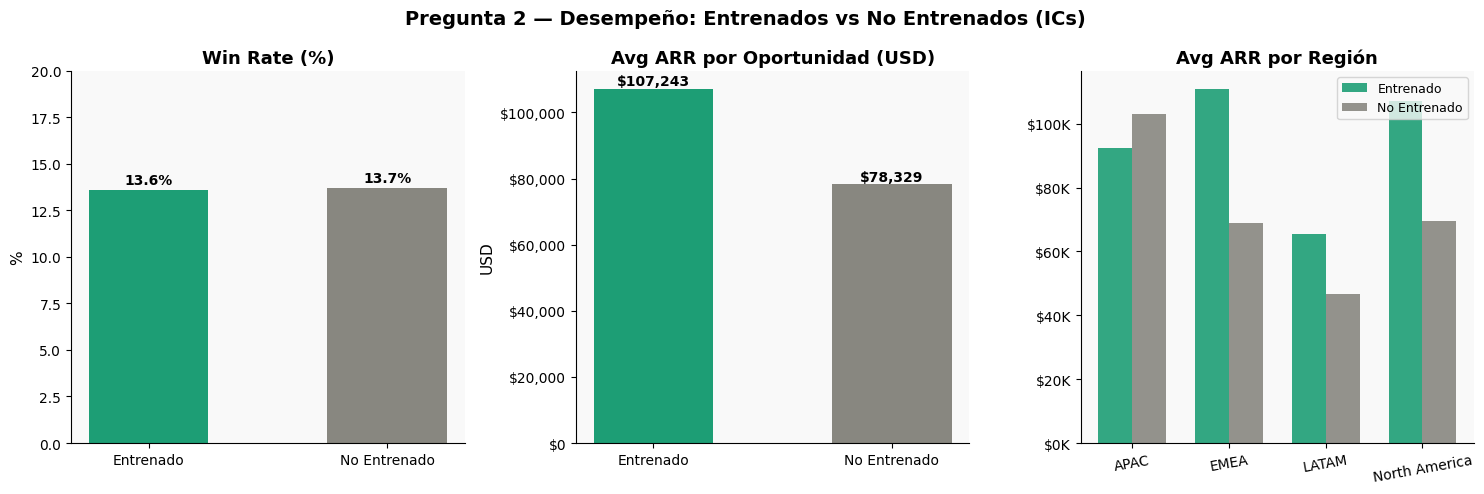

In [ ]:
# ── 2F. Visualizaciones ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Pregunta 2 — Desempeño: Entrenados vs No Entrenados (ICs)', fontsize=14, fontweight='bold')

COLORS = {'Entrenado': '#1D9E75', 'No Entrenado': '#888780'}
labels = ['Entrenado', 'No Entrenado']

# Gráfica 1: Win Rate
ax1 = axes[0]
win_rates = global_metrics.set_index('Trained Label')['Win Rate (%)'].reindex(labels)
bars = ax1.bar(labels, win_rates, color=[COLORS[l] for l in labels], width=0.5)
ax1.set_title('Win Rate (%)', fontweight='bold')
ax1.set_ylim(0, 20)
ax1.set_ylabel('%')
for bar, val in zip(bars, win_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

# Gráfica 2: Avg ARR por Oportunidad
ax2 = axes[1]
avg_arr = global_metrics.set_index('Trained Label')['Avg ARR por Opp (USD)'].reindex(labels)
bars2 = ax2.bar(labels, avg_arr, color=[COLORS[l] for l in labels], width=0.5)
ax2.set_title('Avg ARR por Oportunidad (USD)', fontweight='bold')
ax2.set_ylabel('USD')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars2, avg_arr):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1000, f'${val:,.0f}', ha='center', fontweight='bold', fontsize=10)

# Gráfica 3: Avg ARR por región
ax3 = axes[2]
reg_pivot = (
    region_metrics[region_metrics['Trained Label'].isin(labels)]
    .pivot(index='Region', columns='Trained Label', values='Avg ARR por Opp (USD)')
    [labels]
)
x = np.arange(len(reg_pivot))
w = 0.35
ax3.bar(x - w/2, reg_pivot['Entrenado'],    w, label='Entrenado',    color='#1D9E75', alpha=0.9)
ax3.bar(x + w/2, reg_pivot['No Entrenado'], w, label='No Entrenado', color='#888780', alpha=0.9)
ax3.set_xticks(x)
ax3.set_xticklabels(reg_pivot.index, rotation=10)
ax3.set_title('Avg ARR por Región', fontweight='bold')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Respuesta — Pregunta 2

#### Hallazgo principal: El entrenamiento aumenta el valor por deal, no el volumen

| Métrica | Entrenados | No Entrenados | Diferencia |
|---|---|---|---|
| Total oportunidades | 339 | 262 | — |
| Win Rate | 13.6% | 13.7% | ~0% |
| **Avg ARR por oportunidad** | **$107,243** | **$78,329** | **+37%** |
| Total ARR generado | $36.4M | $20.5M | +77% |

#### ¿Qué significa esto?
El win rate es prácticamente idéntico entre ambos grupos — el entrenamiento **no parece aumentar
la probabilidad de cerrar un deal**. Sin embargo, los empleados entrenados generan en promedio
**37% más ARR por oportunidad** ($107K vs $78K). Esto sugiere que el entrenamiento ayuda a los
AEs a **posicionarse en deals de mayor valor** o a **vender soluciones de mayor alcance** (Suite).

#### Por Región:
- **EMEA y North America:** Los entrenados tienen ARR significativamente mayor. EMEA muestra
  el gap más claro: $111K (entrenados) vs $69K (no entrenados) — +61%.
- **APAC:** Inversión del patrón — no entrenados tienen mayor ARR. Posible efecto de
  datos escasos (solo 8 oportunidades de entrenados en APAC).
- **LATAM:** Similar inversión, también con volumen muy bajo.

#### Presentación recomendada para stakeholders:
Enfocar el mensaje en el **impacto en ARR** más que en win rate. El argumento es:
> *"Los empleados entrenados no cierran más deals, pero los deals que cierran valen 37% más.
> Con el mismo número de oportunidades, un equipo 100% entrenado generaría ~$18M de ARR
> adicional en nuestro pipeline actual."*

#### Limitaciones del análisis:
- Solo 601 oportunidades — tamaño de muestra limitado para conclusiones estadísticas robustas.
- Correlación no implica causalidad: los AEs más senior o con mejores territorios pueden
  tener más probabilidad tanto de entrenar como de tener deals más grandes.
- Datos de pipeline incompletos: 86% de las oportunidades no están cerradas aún.


---
## Pregunta 3 — Insights Adicionales, Calidad de Datos y Recomendaciones

Esta sección explora hallazgos adicionales, problemas identificados en los datos y sugerencias
para enriquecer el análisis.


In [ ]:
# ── 3A. Calidad de datos ───────────────────────────────────────────────────
print('='*55)
print('PROBLEMAS DE CALIDAD DE DATOS')
print('='*55)

# IDs en training sin match en employee
orphan_train = set(train['Employee_ID']) - set(emp['Employee_ID'])
print(f'\n[CRÍTICO] Employee_IDs en Trainings sin match en Employee_Data:')
print(f'  → {len(orphan_train):,} IDs huérfanos ({len(orphan_train)/train["Employee_ID"].nunique()*100:.1f}% del total)')
print(f'  → Impacto: estos registros no se pueden atribuir a ningún empleado activo.')
print(f'  → Causa probable: empleados que ya salieron de la empresa (attrition).')

# IDs en performance sin match
orphan_perf = set(perf['Employee_ID']) - set(emp['Employee_ID'])
print(f'\n[MODERADO] Employee_IDs en Performance sin match en Employee_Data:')
print(f'  → {len(orphan_perf):,} IDs — impacto mínimo pero requiere verificación.')

# Oportunidades en etapas tempranas
stage_dist = perf['Stage'].value_counts(normalize=True) * 100
closed_pct = perf['Is Closed Won'].mean() * 100
print(f'\n[MODERADO] Solo {closed_pct:.1f}% de oportunidades están cerradas/ganadas.')
print(f'  → El 54% están en etapa 02-Discovery (etapa más temprana).')
print(f'  → Limita el análisis de win rate — no es estadísticamente representativo.')

# Cobertura de performance por región
print(f'\n[OBSERVACIÓN] Cobertura de oportunidades por región:')
emp_region = emp['Region'].value_counts()
perf_region = perf.merge(emp[['Employee_ID','Region']], on='Employee_ID', how='left')['Region'].value_counts()
for r in emp_region.index:
    emp_n = emp_region.get(r, 0)
    perf_n = perf_region.get(r, 0)
    print(f'  {r:<15} {emp_n:>5} empleados | {perf_n:>4} oportunidades | ratio: {perf_n/emp_n:.2f}')

PROBLEMAS DE CALIDAD DE DATOS

[CRÍTICO] Employee_IDs en Trainings sin match en Employee_Data:
  → 200 IDs huérfanos (16.8% del total)
  → Impacto: estos registros no se pueden atribuir a ningún empleado activo.
  → Causa probable: empleados que ya salieron de la empresa (attrition).

[MODERADO] Employee_IDs en Performance sin match en Employee_Data:
  → 2 IDs — impacto mínimo pero requiere verificación.

[MODERADO] Solo 13.8% de oportunidades están cerradas/ganadas.
  → El 54% están en etapa 02-Discovery (etapa más temprana).
  → Limita el análisis de win rate — no es estadísticamente representativo.

[OBSERVACIÓN] Cobertura de oportunidades por región:
  North America    1064 empleados |  293 oportunidades | ratio: 0.28
  EMEA              699 empleados |  193 oportunidades | ratio: 0.28
  APAC              543 empleados |   92 oportunidades | ratio: 0.17
  LATAM             226 empleados |   27 oportunidades | ratio: 0.12


In [ ]:
# ── 3B. Insights adicionales ────────────────────────────────────────────────
print('='*55)
print('INSIGHTS ADICIONALES')
print('='*55)

# Mix de oportunidades
print(f'\n[INSIGHT 1] Composición del pipeline:')
print(perf['Type'].value_counts().to_string())
print(f'  → El 91% son Expansion (negocio existente). Solo el 9% es New Business.')
print(f'  → Indica una estrategia de crecimiento basada en expansión de clientes actuales.')

# Advocacy - el mayor cost center sin training requirement
print(f'\n[INSIGHT 2] Advocacy — exentos de Sell More Suite SKU:')
advocacy = emp[emp['Cost Center Family'] == 'Advocacy']
advocacy_trained = advocacy['Employee_ID'].isin(trained_ids)
print(f'  → {len(advocacy):,} empleados ({len(advocacy)/len(emp)*100:.1f}% del total)')
print(f'  → De ellos, {advocacy_trained.sum()} completaron algún entrenamiento voluntariamente.')

# Distribución de length of service
print(f'\n[INSIGHT 3] Relación entrenamiento y antigüedad:')
emp_los = emp.copy()
los_trained   = emp_los[emp_los['Trained']]['Length of service'].mean()
los_untrained = emp_los[~emp_los['Trained']]['Length of service'].mean()
print(f'  → Antigüedad promedio entrenados:    {los_trained:.1f} meses')
print(f'  → Antigüedad promedio no entrenados: {los_untrained:.1f} meses')

# ARR máximo
max_arr = perf['Total Commissionable ARR (converted)'].max()
print(f'\n[INSIGHT 4] Outlier en ARR:')
print(f'  → Oportunidad máxima: ${max_arr:,.0f} USD — 48x el promedio.')
print(f'  → Revisar si es un dato correcto o un error de entrada.')

INSIGHTS ADICIONALES

[INSIGHT 1] Composición del pipeline:
Type
Expansion       552
New Business     55
  → El 91% son Expansion (negocio existente). Solo el 9% es New Business.
  → Indica una estrategia de crecimiento basada en expansión de clientes actuales.

[INSIGHT 2] Advocacy — exentos de Sell More Suite SKU:
  → 516 empleados (20.4% del total)
  → De ellos, 80 completaron algún entrenamiento voluntariamente.

[INSIGHT 3] Relación entrenamiento y antigüedad:
  → Antigüedad promedio entrenados:    31.4 meses
  → Antigüedad promedio no entrenados: 31.2 meses

[INSIGHT 4] Outlier en ARR:
  → Oportunidad máxima: $4,570,063 USD — 48x el promedio.
  → Revisar si es un dato correcto o un error de entrada.


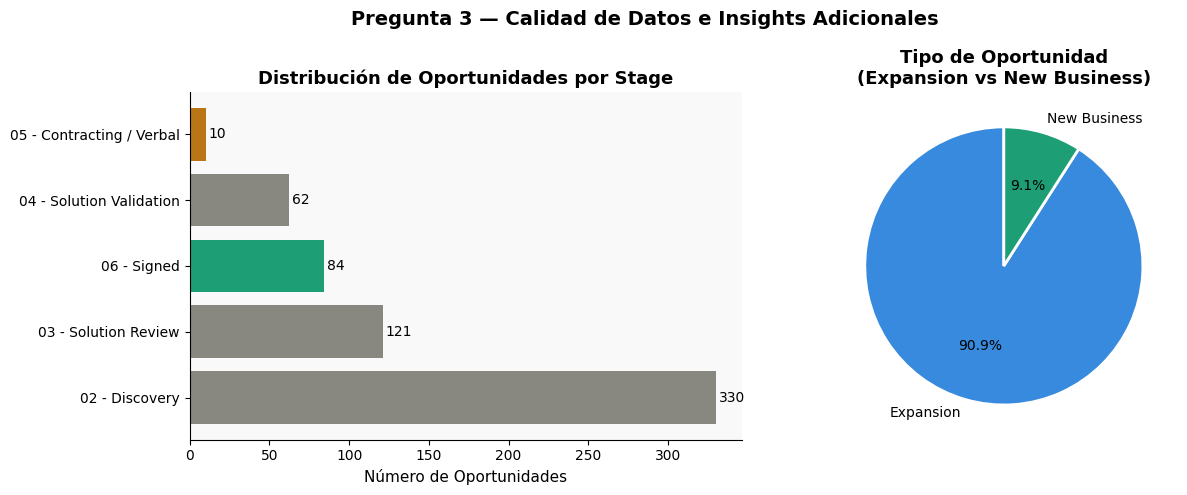

In [ ]:
# ── 3C. Visualización — distribución de stages y pipeline ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Pregunta 3 — Calidad de Datos e Insights Adicionales', fontsize=14, fontweight='bold')

# Chart 1: Distribución de stages
ax1 = axes[0]
stage_counts = perf['Stage'].value_counts()
stage_colors = ['#1D9E75' if '06' in s or '07' in s else '#BA7517' if '05' in s else '#888780' for s in stage_counts.index]
bars = ax1.barh(stage_counts.index, stage_counts.values, color=stage_colors)
ax1.set_title('Distribución de Oportunidades por Stage', fontweight='bold')
ax1.set_xlabel('Número de Oportunidades')
for bar, val in zip(bars, stage_counts.values):
    ax1.text(val + 2, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)

# Chart 2: Tipo de oportunidad
ax2 = axes[1]
type_counts = perf['Type'].value_counts()
ax2.pie(type_counts.values, labels=type_counts.index,
        autopct='%1.1f%%', colors=['#378ADD','#1D9E75'],
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Tipo de Oportunidad\n(Expansion vs New Business)', fontweight='bold')

plt.tight_layout()
plt.show()

### Respuesta — Pregunta 3

#### Problemas de calidad de datos

**1. 200 Employee_IDs en `Completed_Trainings` sin match en `Employee_Data`** *(Crítico)*
Representa ~13% de los IDs únicos de entrenamiento. La causa más probable es *attrition*:
empleados que completaron el entrenamiento pero ya no están en la empresa. Esto infla
artificialmente el conteo total de completaciones si no se filtra correctamente.

**2. Solo 14% de oportunidades en etapas cerradas** *(Moderado)*
La mayoría del pipeline está en etapa 02-Discovery (54%). Esto limita la validez estadística
del win rate y hace difícil sacar conclusiones definitivas sobre efectividad de ventas.

**3. Cobertura desigual entre regiones** *(Observación)*
APAC tiene 543 empleados pero solo genera 0.17 oportunidades por empleado (vs 0.44 en EMEA).
Puede indicar que el proceso de captura de datos en CRM es inconsistente entre regiones.

**4. Outlier extremo de ARR** *(Verificar)*
Una oportunidad tiene $4.57M USD de ARR — 48x el promedio. Requiere validación manual.

#### Insights adicionales interesantes

- **Pipeline dominado por Expansion (91%):** La estrategia de crecimiento es claramente
  de expansión en clientes existentes. El entrenamiento en Suite products tiene sentido
  en este contexto — los AEs necesitan conocer el portfolio completo para upsell/cross-sell.

- **Leaders 8 y 13 con 0% de completación:** No hay ninguna completación de Sell More Suite SKU
  registrada. Puede ser un problema de datos o una falta real de adopción.

- **Advocacy voluntariamente entrenados:** Aunque exentos del curso de SKU, algunos empleados
  de Advocacy completaron entrenamientos, lo que sugiere motivación intrínseca.

#### Datos adicionales que mejorarían el análisis

| Dato | Por qué sería útil |
|---|---|
| Fecha de completación del entrenamiento | Analizar si el desempeño mejora *después* del entrenamiento (causalidad) |
| Quota asignada por AE | Normalizar el ARR por empleado y distinguir territory size |
| Historial completo de pipeline (2+ años) | Suficiente muestra para análisis estadístico robusto |
| Satisfacción / NPS del entrenamiento | Medir calidad del entrenamiento, no solo completación |
| Tenure del empleado al momento del entrenamiento | Controlar por experiencia en el análisis |


---
## Resumen Ejecutivo

### Hallazgos clave

1. **Completación de entrenamientos:** Los cursos técnicos tienen excelente adopción (>90%),
   pero Sell More Suite SKU está en solo 40.2% globalmente. APAC es la región más rezagada
   con apenas 7.7%, y dos líderes tienen 0% de completación — acción prioritaria requerida.

2. **Impacto del entrenamiento:** Los AEs entrenados generan **37% más ARR por oportunidad**
   ($107K vs $78K). El win rate es similar, lo que sugiere que el entrenamiento ayuda a
   posicionarse en deals de mayor valor, no necesariamente a cerrar más.

3. **Calidad de datos:** Hay problemas relevantes (200 IDs huérfanos, pipeline poco maduro)
   que limitan la robustez estadística — se recomienda enriquecer los datos antes de
   tomar decisiones estratégicas con estos resultados.

### Próximos pasos recomendados
- Investigar y resolver los 0% de completación de Leaders 8 y 13.
- Diseñar un plan de acción específico para APAC en Sell More Suite SKU.
- Incorporar fechas de entrenamiento para análisis de causalidad (antes/después).
- Agregar datos de quota para normalizar métricas de ARR por empleado.
